# 05 — Segmentation: trading dictionary area for acquisition time

So far the match line has been one 4092-bit word with one threshold. This notebook splits it
into $S$ sub-lines, each with its own threshold, combined by counting fires.

That single change is the architecture's main design knob, and it cuts both ways:

- **It shrinks the dictionary** — a shorter coherent interval needs fewer Doppler rows.
- **It costs sensitivity** — each segment is *hard-decided* before combining.

By the end you should be able to answer:

1. Why must $S$ divide 2046, and why are powers of two mostly unavailable?
2. Exactly *why* does segmentation buy Doppler tolerance? (the answer is subtler than "shorter dwell")
3. How much sensitivity does the hard decision cost, measured?
4. What is the $k$-of-$S$ accumulator actually doing?

Modules: [`sim/gps/segment.py`](../sim/gps/segment.py),
[`sim/gps/segmentation_study.py`](../sim/gps/segmentation_study.py).

In [1]:
import sys, pathlib, math
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from sim.gps import codebook
from sim.gps.segment import SegmentedCAM, detect
from sim.gps.experiments import (GpsConfig, build, cached_distances, dictionary_bits,
                                 dwell_keys, independent_cells)

plt.rcParams.update({"figure.figsize": (9, 3), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

T = 1e-3
theory = lambda cn0, t: math.sqrt(2 * 10 ** (cn0 / 10) * t) * math.sqrt(2 / math.pi)

---
## 1. What a segmented match line is

[`SegmentedCAM`](../sim/gps/segment.py) is $S$ independent CAMs over contiguous slices of the
*same* rows. Nothing about the dictionary changes — only how the comparison is read out.

```
one match line:    [============== 4092 bits, one threshold ==============]  -> 1 bit out

S = 6 segments:    [== 682 ==][== 682 ==][== 682 ==][== 682 ==][== 682 ==][== 682 ==]
                       tau       tau        tau        tau        tau        tau
                        |         |          |          |          |          |
                        +---------+----------+---- popcount >= k --+----------+  -> 1 bit out
```

In [2]:
cfg = GpsConfig(n_segments=6, n_prn=3)
cb, scam = build(cfg)
print(f"rows       : {cb.rows.shape}   (unchanged by segmentation)")
print(f"S          : {scam.S} segments of {scam.seg_width} bits each")
print(f"check      : {scam.S} x {scam.seg_width} = {scam.S*scam.seg_width} = W")
print(f"T_coh      : {cfg.t_coh*1e6:.1f} us  (= 1 ms / {scam.S})")
print(f"Doppler rows/PRN: {len(cb.fd_grid)}  (was 41 unsegmented)")

rows       : (27, 4092)   (unchanged by segmentation)
S          : 6 segments of 682 bits each
check      : 6 x 682 = 4092 = W
T_coh      : 166.7 us  (= 1 ms / 6)
Doppler rows/PRN: 9  (was 41 unsegmented)


---
## 2. The awkward constraint: $S$ must divide 2046

A segment cannot be a fractional number of samples, so $S$ has to divide $N_s = 2046$. And

$$ 2046 = 2 \times 3 \times 11 \times 31 $$

which contains no useful powers of two. You cannot have $S = 4$, $8$, or $16$ — a genuinely
annoying hardware constraint, since binary trees are what popcount logic likes.

In [3]:
div = codebook.segment_counts(2046)
print("divisors of 2046 up to 40:", [s for s in div if s <= 40])
print("powers of two available  :", [s for s in [2, 4, 8, 16, 32] if s in div])
print()
print("The usable ladder is S = 1, 2, 3, 6, 11 (then 22, 31, 33).")
print("Note this is an artifact of OSR=2. At OSR=4, N_s = 4092 = 2^2*3*11*31, which adds S=4.")

divisors of 2046 up to 40: [1, 2, 3, 6, 11, 22, 31, 33]
powers of two available  : [2]

The usable ladder is S = 1, 2, 3, 6, 11 (then 22, 31, 33).
Note this is an artifact of OSR=2. At OSR=4, N_s = 4092 = 2^2*3*11*31, which adds S=4.


---
## 3. What it buys: the dictionary shrinks

Notebook 01 established that the Doppler bin spacing is $1/(2T_{\text{coh}})$. Shorten
$T_{\text{coh}}$ and the sinc widens, so fewer bins cover $\pm10$ kHz:

$$ n_{f_d} = 2\left\lceil 2 f_{\max} T_{\text{coh}} \right\rceil + 1, \qquad T_{\text{coh}} = \frac{1\ \text{ms}}{S} $$

Since the dictionary is (32 PRN) $\times$ $n_{f_d}$ $\times$ (row state bits), it shrinks in
direct proportion.

In [4]:
rows_tbl = []
for S in [1, 2, 3, 6, 11, 22]:
    cf = GpsConfig(n_segments=S, n_prn=32)
    nd = len(codebook.doppler_grid(cf.f_max, cf.t_coh))
    rows_tbl.append((S, cf.t_coh * 1e6, nd, dictionary_bits(cf) / 1e6, independent_cells(cf)))

print(f"{'S':>3} {'T_coh (us)':>11} {'Doppler rows':>13} {'dictionary':>12} {'search cells':>13}")
for S, t, nd, mb, cells in rows_tbl:
    print(f"{S:>3} {t:>11.1f} {nd:>13} {mb:>9.2f} Mbit {cells:>13,}")
print(f"\nS=1 -> S=11 shrinks the dictionary {rows_tbl[0][3]/rows_tbl[4][3]:.1f}x")

  S  T_coh (us)  Doppler rows   dictionary  search cells
  1      1000.0            41      5.37 Mbit     1,342,176
  2       500.0            21      2.75 Mbit       687,456
  3       333.3            15      1.96 Mbit       491,040
  6       166.7             9      1.18 Mbit       294,624
 11        90.9             5      0.65 Mbit       163,680
 22        45.5             3      0.39 Mbit        98,208

S=1 -> S=11 shrinks the dictionary 8.2x


---
## 4. Why does this actually work? (the subtle part)

The tempting explanation is "a shorter dwell tolerates more Doppler". True, but it is *not*
the mechanism — and the difference matters.

**Hamming distance is additive across segments.** The full-word distance is exactly the sum of
the segment distances, always. So if you *summed* the segments and thresholded the total, you
would have rebuilt the unsegmented 1 ms detector bit for bit — and it would still need all 41
Doppler rows.

In [5]:
d = cached_distances(GpsConfig(n_segments=6, n_prn=3), cn0=38.0, trials=3000, seed=42)
al = d["aligned"]
print(f"per-segment distances, shape {al.shape}  (trials x S)")
print(f"first trial's 6 segments: {al[0]}  -> sum {al[0].sum()}")
print()
print("Summing segments recovers the full-word distance exactly -- so a SUM detector")
print("is the unsegmented detector, and would need the full 41-row Doppler grid.")

per-segment distances, shape (3000, 6)  (trials x S)
first trial's 6 segments: [320 317 321 331 303 324]  -> sum 1916

Summing segments recovers the full-word distance exactly -- so a SUM detector
is the unsegmented detector, and would need the full 41-row Doppler grid.


**The Doppler tolerance appears only because each segment is thresholded *before* combining.**
That hard decision is what breaks coherence between segments — and breaking coherence is
precisely what makes a residual Doppler ramp harmless, because the ramp's phase rotation no
longer has to stay small across the *whole* word, only across one segment.

So the trade is not "shorter dwell, less signal". It is:

> **You are paying for Doppler tolerance with a hard decision, and hard decisions lose
> information.**

Let's price it. Same measured distances, same $S$, two ways of combining.

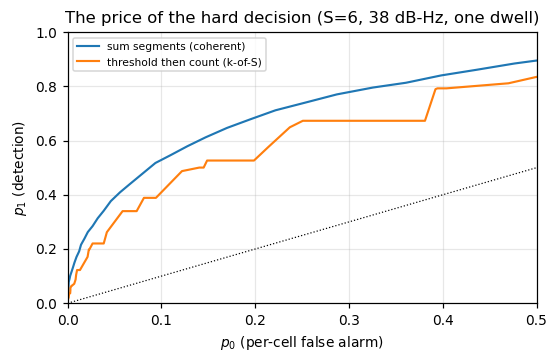

 target p0      sum   k-of-S     loss
      0.30    0.770    0.673    0.097
      0.10    0.517    0.389    0.129
      0.03    0.284    0.220    0.064
      0.01    0.171    0.122    0.049


In [6]:
wr = np.concatenate([d[k] for k in ("wrong_phase", "wrong_doppler", "wrong_prn")])
sa, sw = al.sum(1), wr.sum(1)                       # detector A: sum, then threshold

roc_sum = np.array([[(sa <= t).mean(), (sw <= t).mean()]
                    for t in range(int(sw.min()), int(sw.max()) + 1, 2)])
roc_hard = np.array([[((al <= tau).sum(1) >= k).mean(), ((wr <= tau).sum(1) >= k).mean()]
                     for tau in range(int(wr.min()), int(wr.max()) + 1, 2)
                     for k in range(1, al.shape[1] + 1)])

fig, ax = plt.subplots(figsize=(5.5, 3.2))
o = np.argsort(roc_sum[:, 1]); ax.plot(roc_sum[o, 1], roc_sum[o, 0], lw=1.4, label="sum segments (coherent)")
h = roc_hard[np.argsort(roc_hard[:, 1])]
ax.plot(h[:, 1], np.maximum.accumulate(h[:, 0]), lw=1.4, label="threshold then count (k-of-S)")
ax.plot([0, 1], [0, 1], "k:", lw=0.8)
ax.set(xlabel="$p_0$ (per-cell false alarm)", ylabel="$p_1$ (detection)", xlim=(0, 0.5), ylim=(0, 1),
       title="The price of the hard decision (S=6, 38 dB-Hz, one dwell)")
ax.legend(fontsize=7); plt.show()

print(f"{'target p0':>10} {'sum':>8} {'k-of-S':>8} {'loss':>8}")
for t in [0.3, 0.1, 0.03, 0.01]:
    pa = roc_sum[roc_sum[:, 1] <= t][:, 0].max() if (roc_sum[:, 1] <= t).any() else 0
    pb = roc_hard[roc_hard[:, 1] <= t][:, 0].max() if (roc_hard[:, 1] <= t).any() else 0
    print(f"{t:>10.2f} {pa:>8.3f} {pb:>8.3f} {pa-pb:>8.3f}")

At $p_0 = 0.1$ the hard decision costs about **13 points of detection probability** in a single
dwell (0.52 → 0.39). That is the real, measured price of the Doppler-row saving in section 3 —
and it is the reason the Pareto curve in notebook 07 slopes the way it does rather than being
a free lunch.

---
## 5. The other cost: each segment sees less signal

A segment is $1/S$ of the dwell, so its own margin follows the notebook 04 formula with
$T \to T/S$:

$$ \left.\frac{\Delta}{\sigma_d}\right|_{\text{segment}} = \sqrt{2\,(C/N_0)\,\frac{T}{S}}\cdot\sqrt{2/\pi} \;=\; \frac{1}{\sqrt S}\left.\frac{\Delta}{\sigma_d}\right|_{\text{full}} $$

In [7]:
print(f"{'S':>3} {'T_coh (us)':>11} {'predicted':>10} {'measured':>10} {'ratio':>8}")
for S in [1, 2, 3, 6, 11]:
    dd = cached_distances(GpsConfig(n_segments=S, n_prn=3), cn0=38.0, trials=3000, seed=42)
    a, w = dd["aligned"].ravel(), np.concatenate([dd[k].ravel() for k in
                                                  ("wrong_phase", "wrong_doppler", "wrong_prn")])
    meas = (w.mean()-a.mean())/w.std()
    print(f"{S:>3} {T/S*1e6:>11.1f} {theory(38, T/S):>10.2f} {meas:>10.2f} {meas/theory(38, T/S):>8.2f}")

  S  T_coh (us)  predicted   measured    ratio
  1      1000.0       2.83       2.65     0.93
  2       500.0       2.00       1.51     0.75
  3       333.3       1.64       1.08     0.66
  6       166.7       1.16       0.58     0.51
 11        90.9       0.85       0.32     0.38


At $S = 11$ a single segment carries a margin of about 0.3$\sigma$ — individually useless. The
detector only works because *many* weak segments are counted, across segments **and** across
dwells. Which is the next section.

### Segmentation costs more than $1/\sqrt S$

Look at the ratio column: it is not flat. Measured margin degrades **faster** than the
$1/\sqrt S$ law predicts — 0.94 of theory at $S=1$, but only 0.38 at $S=11$.

The reason is the quadrant sweep, applied *per segment*. Each segment independently takes the
best of its four rotations. When a segment is long, the signal decides which rotation wins.
When a segment is short and its own margin is well under 1$\sigma$, **noise** decides — the
minimum is selected by whichever rotation got lucky, not by the one matching $\theta_0$. The
sweep stops being a phase search and starts being a noise-minimizer.

So there is a third cost to segmentation, on top of the shorter coherent interval (§5) and the
hard decision (§4). It is not in the analytic model, which is exactly why the study measures
$p_1$ and $p_0$ rather than computing them.

---
## 6. The $k$-of-$S$ accumulator

[`segment.detect`](../sim/gps/segment.py) does the combining, and it accumulates on two axes
at once:

- **within a dwell**: the four $\theta_0$ quadrants are **OR**-ed (the boolean stand-in for a
  magnitude — notebook 03 §4)
- **across dwells**: segment fire counts are **summed**

so after $M$ dwells the statistic is a count out of $M \times S$, compared against $k$.
Everything here consumes booleans; `CAM.query` remains the only thing that ever sees a distance.

In [8]:
rows = np.random.default_rng(2).integers(0, 2, size=(5, 96))
sc = SegmentedCAM(rows, n_segments=3)
keys = np.random.default_rng(3).integers(0, 2, size=(4, 96))     # the 4 quadrant rotations

one = detect(sc, [keys], tau=40, k=1)
two = detect(sc, [keys, keys], tau=40, k=1)
print("fire counts after 1 dwell :", one.fire_count)
print("fire counts after 2 dwells:", two.fire_count, " (exactly doubled -- accumulation is linear)")
print("declared present (k=1)    :", two.fired)

fire counts after 1 dwell : [3 3 3 3 3]
fire counts after 2 dwells: [6 6 6 6 6]  (exactly doubled -- accumulation is linear)
declared present (k=1)    : [ True  True  True  True  True]


### Why non-coherent accumulation suits this architecture

Notebook 01 showed one dwell is never enough at 38 dB-Hz, *for any receiver*. So multi-dwell
accumulation is mandatory regardless — and a conventional receiver must pay for it with
squarers and adders holding real-valued magnitudes.

Here it is a **counter**. The boolean readout that costs so much in notebook 02's accounting
happens to make the mandatory part nearly free. That is the honest form of the architecture's
pitch: not "binary is better", but "GNSS acquisition needs exactly the thing binary is good at".

---
## What we established

| Fact | Consequence |
|---|---|
| $S$ must divide $2046 = 2{\cdot}3{\cdot}11{\cdot}31$ | the ladder is 1, 2, 3, 6, 11 — no powers of two |
| $n_{f_d}$ shrinks with $T_{\text{coh}}$: 41 → 5 rows | dictionary 5.37 → 0.65 Mbit, an 8.2× saving |
| Hamming is additive, so *summing* segments = the unsegmented detector | the tolerance comes from the **pre-threshold**, not the short dwell |
| The hard decision costs ~13 points of $p_1$ at $p_0=0.1$ | this is what the area saving is bought with |
| Per-segment margin falls as $1/\sqrt S$ | at $S=11$ a segment is under $1\sigma$ on its own |
| Accumulation is a counter over $M \times S$ | the mandatory multi-dwell step is nearly free here |

## Next

**Notebook 06 — `sense_margin.ipynb`.** We have been choosing $\tau$ by eye. The real question
for a circuit designer is *how precisely must the match line resolve a distance* — one part in
how many? Notebook 03 showed the aligned row sits barely 2% below chance, so the answer is
uncomfortable, and segmentation turns out to help for a second, independent reason.

### Try it yourself
- Redo §4's ROC at 42 dB-Hz. Does the hard-decision penalty grow or shrink with C/N0?
- In §3, what would the ladder look like at OSR = 4 ($N_s = 4092$)? Does $S = 4$ help?
- In §6, set `tau` so that roughly half the segments fire. What does `k` have to be for the count to mean anything?